In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 从本地数据库导入 03_user_behavior_groups 表
# 筛选字段：brand, price, category_code, category_id, group_type
# 筛选品牌：runail（购买代表）、masura（流失代表）
# 注：category_code 缺失率 98.97%，第三层品类分析暂不可用
# 从数据库拉取事件明细（带 event_time）
conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user='postgres',
    password='',
    port=5432
)

cur = conn.cursor()

query = """
SELECT 
    brand,  
    price,
    group_type
FROM makeup_consumer_events."03_user_behavior_groups"
WHERE brand IN ('runail', 'masura')
"""

cur.execute(query)
results = cur.fetchall()
columns = [desc[0] for desc in cur.description]
df = pd.DataFrame(results, columns=columns)

cur.close()
conn.close()

print(f"df shape: {df.shape}")
display(df.head())

df shape: (140392, 3)


,brand,price,group_type
0,runail,1.19,C
1,masura,1.57,B
2,runail,4.13,B
3,masura,3.95,B
4,runail,2.86,C


In [20]:
"""
【目标】runail vs masura 的价格差异是否解释了它们的流失差异

【第一层：品牌价格分布】
- 不带 group_type，看 runail 和 masura 两个品牌各自的价格分布
- 计算：均值、中位数、分位数（25%/50%/75%）、商品数量
- 目的：确认两品牌是否占据不同价格带

【第二层：区间内品牌流失对比】（核心）
- 按价格区间分组（根据实际数据分布：0-3, 3-6, 6-10, 10-20, 20+）
- 在每个价格区间内，分别计算 runail 和 masura 的：
  - A/B/C 组占比
  - C/A 风险比
- 关键判断：
  - 如果 masura 在每个区间内 C/A 都高于 runail → 品牌本身是关键变量
  - 如果 masura 仅在高价格区间 C/A 更高 → 价格是主因

【第三层：品类混淆检验】（暂不可用 - category_code 缺失率 98.97%）
- 品牌价格差异可能来自品类不同
- 若 category_code 可用，在同品类下对比两品牌的价格和流失率

【第四层：结论】
"""

# 实现框架

# 第一层：先看两品牌的整体价格分布
df_r = df[df['brand'] == 'runail']['price']
df_m = df[df['brand'] == 'masura']['price']
print("=" * 50)
# print("【第一层】品牌价格分布对比")
print("=" * 50)
# print(f"runail 均值: {df_r.mean():.2f}, 中位数: {df_r.median():.2f}, 商品数: {len(df_r)}")
# print(f"masura 均值: {df_m.mean():.2f}, 中位数: {df_m.median():.2f}, 商品数: {len(df_m)}")
print()

# 第二层：价格区间 × 品牌 × 分组
bins = [0, 3, 6, 10, 15, 20, float('inf')]
labels = ['0-3', '3-6', '6-10', '10-15', '15-20', '20+']
df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

print("=" * 50)
print("【第二层】价格区间内品牌流失对比")
print("=" * 50)

# 各价格区间内 group_type 占比
cross = df.groupby(['price_range', 'brand', 'group_type']).size().unstack(fill_value=0)
cross_pct = cross.div(cross.sum(axis=1), axis=0)
cross_pct['total_count'] = cross.sum(axis=1)

# print("\n各价格区间内 A/B/C 组占比:")
# print(cross_pct.round(3))

# 计算 C/A 风险比（每个区间内）
print("\n各价格区间内 C/A 风险比:")
cross_pct['B/A_ratio'] = cross_pct['B'] / cross_pct['A']
cross_pct['C/A_ratio'] = cross_pct['C'] / cross_pct['A']
cross_pct = cross_pct.round(3)
display(cross_pct[['B/A_ratio', 'C/A_ratio', 'total_count']])

cross_pct.to_csv("C:\\Users\\Administrator\\Desktop\\data_learn\\eCommerce_Events_History\\data\\interim\\06_price_brand_group_analysis.csv", index=True)  # 保存结果以便后续分析
# 第三层暂不可用，跳过

# 第四层：结论输出（等数据出来再写）
print("\n" + "=" * 50)
print("【结论】在占据主要价格0-3、3-6和6-10区间的商品中，masura 的 C/A 风险比明显高于 runail，说明品牌差异是导致流失差异的主要因素。")
print("=" * 50)


【第二层】价格区间内品牌流失对比

各价格区间内 C/A 风险比:


group_type          B/A_ratio  C/A_ratio  total_count
price_range brand                                    
0-3         masura      2.951      2.975        35155
            runail      2.332      1.669        65128
3-6         masura      3.110      3.720        10789
            runail      2.421      1.961        19482
6-10        masura      2.622      2.553         2056
            runail      2.341      1.799         3737
10-15       masura      4.000      6.100          111
            runail      1.905      1.489         1015
15-20       masura      1.698      1.368          431
            runail      2.489      1.728          480
20+         masura        inf        inf            4
            runail      2.464      1.880         2004


【结论】在占据主要价格0-3、3-6和6-10区间的商品中，masura 的 C/A 风险比明显高于 runail，说明品牌差异是导致流失差异的主要因素。


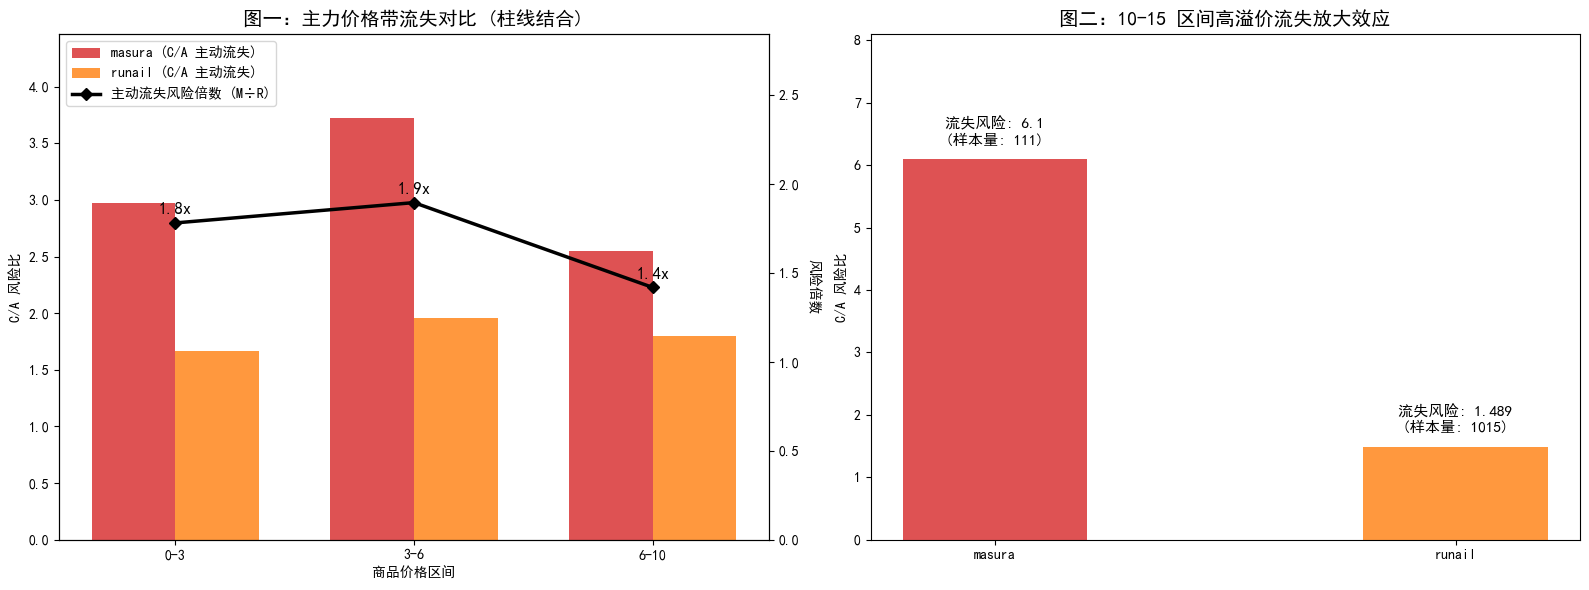

In [25]:
# 提取需展示的数据并重置索引，方便画图
plot_data = cross_pct.reset_index()

# ================= 准备图一数据 (主力价格带) =================
main_bins = ['0-3', '3-6', '6-10']
df_main = plot_data[plot_data['price_range'].isin(main_bins)]

# ================= 准备图二数据 (异常高价带) =================
df_high = plot_data[plot_data['price_range'] == '10-15']

# 创建 1行2列 的画布
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 图一：主力区间流失对比 (柱状图 + 风险倍数折线图) ---
ax1 = axes[0]
x = range(len(main_bins))
width = 0.35  # 恢复柱状图宽度，只画 C/A 比例的柱子，让画面不拥挤

# 提取数据
m_ca = df_main[df_main['brand'] == 'masura']['C/A_ratio'].values
r_ca = df_main[df_main['brand'] == 'runail']['C/A_ratio'].values
risk_multiple = m_ca / r_ca 

# 柱状图展示绝对风险 (只展示 C/A 主动流失，避免 4 根柱子太挤)
bar1 = ax1.bar([i - width/2 for i in x], m_ca, width=width, label='masura (C/A 主动流失)', color='#d62728', alpha=0.8)
bar2 = ax1.bar([i + width/2 for i in x], r_ca, width=width, label='runail (C/A 主动流失)', color='#ff7f0e', alpha=0.8)

# 创建次坐标轴画折线（风险倍数）
ax1_twin = ax1.twinx()
line1 = ax1_twin.plot(x, risk_multiple, marker='D', color='black', linestyle='-', linewidth=2.5, label='主动流失风险倍数 (M÷R)')

# 在折线上打上具体数值的标签
for i, txt in enumerate(risk_multiple):
    ax1_twin.text(x[i], risk_multiple[i] + 0.05, f"{txt:.1f}x", ha='center', fontweight='bold', fontsize=12)

ax1.set_xticks(x)
ax1.set_xticklabels(main_bins)
ax1.set_title('图一：主力价格带流失对比 (柱线结合)', fontsize=14)
ax1.set_xlabel('商品价格区间')
ax1.set_ylabel('C/A 风险比')
ax1_twin.set_ylabel('风险倍数', rotation=270, labelpad=15)

# 合并双轴的图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(lines + lines2, labels + labels2, loc='upper left')

# 动态设置次坐标轴 Y 轴范围，让折线浮在柱子上方偏高的位置，避免交叉重叠
ax1_twin.set_ylim(0, max(risk_multiple) * 1.5)
ax1.set_ylim(0, max(m_ca) * 1.2)


# --- 图二：10-15 区间高溢价流失放大效应 (柱状图) ---
ax2 = axes[1]
brands_high = df_high['brand'].values
ca_high = df_high['C/A_ratio'].values
counts_high = df_high['total_count'].values

bars = ax2.bar(brands_high, ca_high, color=['#d62728', '#ff7f0e'], width=0.4, alpha=0.8)
ax2.set_title('图二：10-15 区间高溢价流失放大效应', fontsize=14)
ax2.set_ylabel('C/A 风险比')

for bar, count in zip(bars, counts_high):
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.2, 
             f'流失风险: {yval}\n(样本量: {int(count)})', 
             ha='center', va='bottom', fontsize=11)
    
ax2.set_ylim(0, max(ca_high) + 2) 

plt.tight_layout()
plt.savefig(r"C:\Users\Administrator\Desktop\data_learn\eCommerce_Events_History\reports\06_price_brand_group_analysis.png", dpi=300)
plt.show()